In [1]:
from LC_utility import *
from pdastro import *

In [2]:
plt.rcParams['axes.labelsize'] =  26     # size of x/y labels
plt.rcParams['xtick.labelsize'] = 18   # size of tick labels
plt.rcParams['ytick.labelsize'] = 18
plt.rcParams['legend.fontsize'] = 24

### load data

In [4]:
### Read in Models
#lcpath = './data/'
lcpath = '../python_fitting/LC_tables/models/'

# before gaussian processing
#LCm2_i = pd.read_csv(lcpath +'M2_iEtaCarLC.csv')
#LCm2_g = pd.read_csv(lcpath +'M2_gEtaCarLC.csv')
#LCm2_r = pd.read_csv(lcpath +'M2_rEtaCarLC.csv')
#LCm2_z = pd.read_csv(lcpath +'M2_zEtaCarLC.csv')

# new model using gaussian processing
LCm2_i = pd.read_csv(lcpath +'iLC_m2.csv')
LCm2_g = pd.read_csv(lcpath +'gLC_m2.csv')
LCm2_r = pd.read_csv(lcpath +'rLC_m2.csv')
LCm2_z = pd.read_csv(lcpath +'zLC_m2.csv')

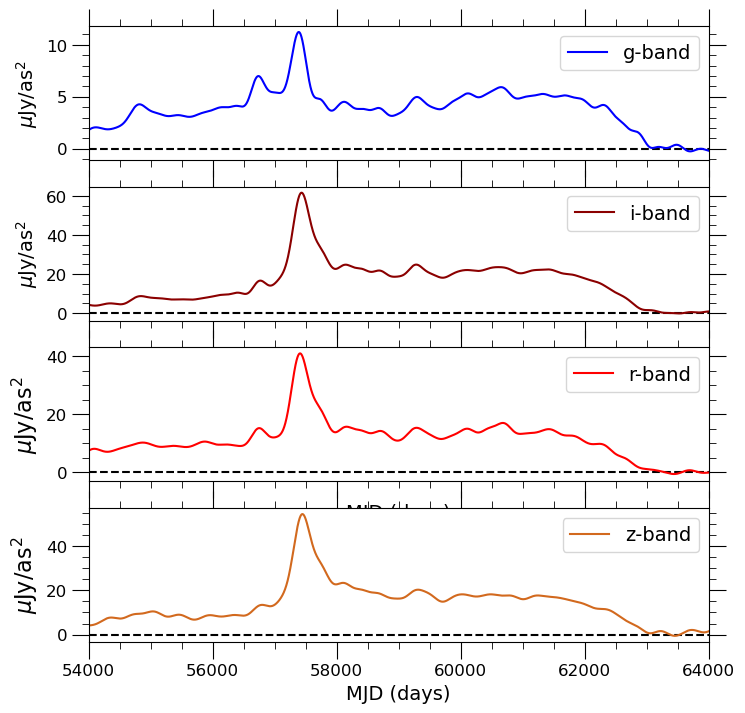

In [6]:
fig, axs = plt.subplots(4,1,dpi = 100, figsize = [8,8], sharex=True)
axs = axs.flatten() 

axs[0].minorticks_on()
axs[0].tick_params(axis='x', labelsize=12)
axs[0].tick_params(axis='y', labelsize=12)
axs[0].tick_params(which='major',bottom='on',top='on',left='on',right='on',length=12)
axs[0].tick_params(which='minor',bottom='on',top='on',left='on',right='on',length=5)
# axs[0].gca().set_xlabel('mjd', fontsize = 14)
axs[0].set_ylabel(r'$\mu$Jy/as$^2$', fontsize = 14)
axs[0].ticklabel_format(axis='both', style='plain')

axs[0].errorbar(LCm2_g['mjd'], LCm2_g['mJyas2'], fmt='-', ecolor='black', color='blue', label='g-band')
axs[0].axhline(y=0, linestyle='--', color='black')
axs[0].set_xlim(54000, 64000)
axs[0].legend(fontsize = 14)


axs[1].minorticks_on()
axs[1].tick_params(axis='x', labelsize=12)
axs[1].tick_params(axis='y', labelsize=12)
axs[1].tick_params(which='major',bottom='on',top='on',left='on',right='on',length=12)
axs[1].tick_params(which='minor',bottom='on',top='on',left='on',right='on',length=5)
axs[1].set_ylabel(r'$\mu$Jy/as$^2$', fontsize = 14)
axs[1].ticklabel_format(axis='both', style='plain')

axs[1].errorbar(LCm2_i['mjd'], LCm2_i['mJyas2'], fmt='-', ecolor='black', color='darkred', label='i-band')
axs[1].axhline(y=0, linestyle='--', color='black')
axs[1].set_xlim(54000, 64000)
axs[1].legend(fontsize = 14)


axs[2].minorticks_on()
axs[2].tick_params(axis='x', labelsize=12)
axs[2].tick_params(axis='y', labelsize=12)
axs[2].tick_params(which='major',bottom='on',top='on',left='on',right='on',length=12)
axs[2].tick_params(which='minor',bottom='on',top='on',left='on',right='on',length=5)
axs[2].set_xlabel('MJD (days)', fontsize = 14)
axs[2].set_ylabel(r'$\mu$Jy/as$^2$', fontsize = 16)
axs[2].ticklabel_format(axis='both', style='plain')

axs[2].errorbar(LCm2_r['mjd'], LCm2_r['mJyas2'], fmt='-', ecolor='black', color='red', label='r-band')
axs[2].axhline(y=0, linestyle='--', color='black')
axs[2].set_xlim(54000, 64000)
axs[2].legend(fontsize = 14)


axs[3].minorticks_on()
axs[3].tick_params(axis='x', labelsize=12)
axs[3].tick_params(axis='y', labelsize=12)
axs[3].tick_params(which='major',bottom='on',top='on',left='on',right='on',length=12)
axs[3].tick_params(which='minor',bottom='on',top='on',left='on',right='on',length=5)
axs[3].set_xlabel('MJD (days)', fontsize = 14)
axs[3].set_ylabel(r'$\mu$Jy/as$^2$', fontsize = 16)
axs[3].ticklabel_format(axis='both', style='plain')

axs[3].errorbar(LCm2_z['mjd'], LCm2_z['mJyas2'], fmt='-', ecolor='black', color='chocolate', label='z-band')
axs[3].axhline(y=0, linestyle='--', color='black')
axs[3].set_xlim(54000, 64000)
axs[3].legend(fontsize = 14)

### convert to AB mag

In [7]:
working_inds_i = np.where(LCm2_i['mJyas2']>0.)[0]
working_inds_g = np.where(LCm2_g['mJyas2']>0.)[0]
working_inds_r = np.where(LCm2_r['mJyas2']>0.)[0]
working_inds_z = np.where(LCm2_z['mJyas2']>0.)[0]

mag_i, mag_err_i = convert_Jy2mag(LCm2_i.loc[working_inds_i,'mJyas2'].values, LCm2_i.loc[working_inds_i,'mJyas2_err'].values)
mag_g, mag_err_g = convert_Jy2mag(LCm2_g.loc[working_inds_g,'mJyas2'].values, LCm2_g.loc[working_inds_g,'mJyas2_err'].values)
mag_r, mag_err_r = convert_Jy2mag(LCm2_r.loc[working_inds_r,'mJyas2'].values, LCm2_r.loc[working_inds_r,'mJyas2_err'].values)
mag_z, mag_err_z = convert_Jy2mag(LCm2_z.loc[working_inds_z,'mJyas2'].values, LCm2_z.loc[working_inds_z,'mJyas2_err'].values)

LCm2_i.loc[working_inds_i,'AB_mag'] = np.array(mag_i)
LCm2_i.loc[working_inds_i,'AB_mag_err'] = np.array(mag_err_i)
LCm2_g.loc[working_inds_g,'AB_mag'] = np.array(mag_g)
LCm2_g.loc[working_inds_g,'AB_mag_err'] = np.array(mag_err_g)
LCm2_r.loc[working_inds_r,'AB_mag'] = np.array(mag_r)
LCm2_r.loc[working_inds_r,'AB_mag_err'] = np.array(mag_err_r)
LCm2_z.loc[working_inds_z,'AB_mag'] = np.array(mag_z)
LCm2_z.loc[working_inds_z,'AB_mag_err'] = np.array(mag_err_z)

In [113]:
t_ran = np.arange(54000, 63500)

i_new = splev(t_ran, splrep(LCm2_i.loc[working_inds_i,'mjd'], LCm2_i.loc[working_inds_i,'AB_mag'], k=1))
# i_new_err = splev(t_ran, splrep(LCm2_i.loc[working_inds_i,'mjd'], LCm2_i.loc[working_inds_i,'AB_mag_err'], k=1))
g_new = splev(t_ran, splrep(LCm2_g.loc[working_inds_g,'mjd'], LCm2_g.loc[working_inds_g,'AB_mag'], k=1))
# g_new_err = splev(t_ran, splrep(LCm2_g.loc[working_inds_g,'mjd'], LCm2_g.loc[working_inds_g,'AB_mag_err'], k=1))

r_new = splev(t_ran, splrep(LCm2_r.loc[working_inds_r,'mjd'], LCm2_r.loc[working_inds_r,'AB_mag'], k=1))
z_new = splev(t_ran, splrep(LCm2_z.loc[working_inds_z,'mjd'], LCm2_z.loc[working_inds_z,'AB_mag'], k=1))

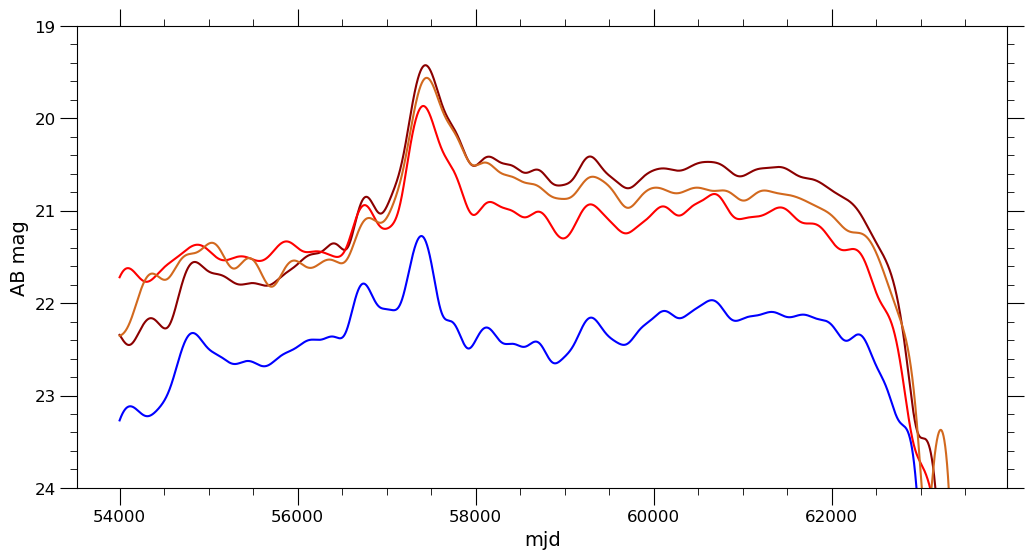

In [114]:
plt.subplots(dpi = 100, figsize = [12,6])
plt.minorticks_on()
plt.tick_params(axis='x', labelsize=12)
plt.tick_params(axis='y', labelsize=12)
plt.tick_params(which='major',bottom='on',top='on',left='on',right='on',length=12)
plt.tick_params(which='minor',bottom='on',top='on',left='on',right='on',length=5)
plt.gca().set_xlabel('mjd', fontsize = 14)
plt.gca().set_ylabel('AB mag', fontsize = 14)
plt.ticklabel_format(axis='both', style='plain')

plt.errorbar(t_ran, g_new, ecolor='black', color='blue')
plt.errorbar(t_ran, i_new, ecolor='black', color='darkred')
plt.errorbar(t_ran, r_new, ecolor='black', color='red')
plt.errorbar(t_ran, z_new, ecolor='black', color='chocolate')

plt.ylim(19,24)
plt.gca().invert_yaxis()

# plt.axvline(54850, color='k', ls='--')
# plt.axvline(56740, color='k', ls='--')
# plt.axvline(57430, color='k', ls='--')
# plt.axvline(59300, color='k', ls='--')

### estimate temperature

- convert SDSS griz to VRI

- estimate color temperature use relations from emperical calibration


#### V-I to Teff

In [90]:
# data from Table 5, A. Alonso et al.: Empirical calibration of Teff versus colours and [Fe/H].

t_effs = np.array([3500,3750,4000,4250,4500,4750,5000,5250,5500,5750,6000,6250,6500,6750,7000,7250,7500,7750,8000 ])

V_Is = np.array([2.800,2.210,1.865,1.625,1.435,1.275,1.135,1.015,0.910,0.815,0.725,0.645,0.575,0.505,0.440,0.380,0.325,0.275,0.225])


Theta = 5040 / t_effs



In [91]:
np.polyfit(V_Is, Theta, deg=3)

array([-0.0192951 ,  0.0197577 ,  0.41923694,  0.53356974])

In [92]:
# V-I to T_eff

def VI_to_Teff(VI):
    """
    Convert (V-I) color to Teff [K] = 5040 / Theta.

    Theta = a0 + a1(V-I) + a2 (V-I)**2 + a3 (V-I)**3
    
    Reference: A. Alonso et al.: Empirical calibration of Teff versus colours and [Fe/H].
    """
    VI = np.asarray(VI)

    # value from np.polyfit
    a3, a2, a1, a0 = -0.0192951 ,  0.0197577 ,  0.41923694,  0.53356974
    
    Theta = a0 + a1 * VI + a2 * VI ** 2 + a3 * VI ** 3
    
    return 5040 / Theta


Text(0, 0.5, 'T eff')

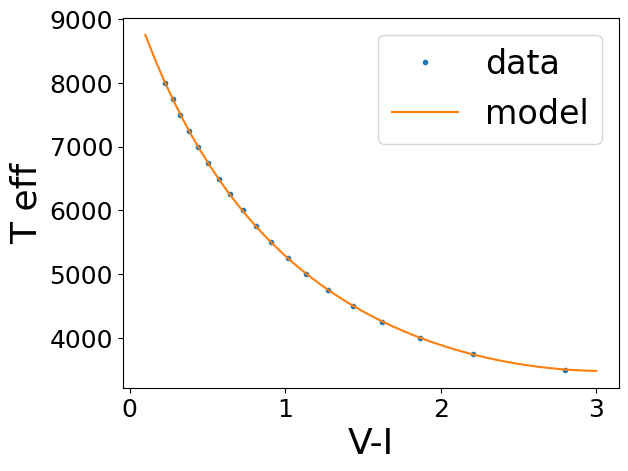

In [95]:
# test fitting

V_I_test = np.linspace(0.1, 3)

Teff_VI_test = VI_to_Teff(V_I_test)

plt.plot(V_Is, t_effs, '.', label='data')
plt.plot(V_I_test, Teff_VI_test, label='model')
plt.legend()
plt.xlabel('V-I')
plt.ylabel('T eff')

#### V-R to Teff

In [73]:
t_effs = np.array([3750,  4000,  4250,  4500,  4750,  5000,  5250, 5500,  5750,  6000, 6250, 6500, 6750, 7000,  7250, 7500, 7750, 8000])

V_Rs = np.array([1.350, 1.145, 0.990, 0.865, 0.760, 0.680, 0.6, 0.535, 0.480, 0.425, 0.380, 0.340, 0.300, 0.265, 0.235, 0.205, 0.180, 0.155])

Theta = 5040 / t_effs


In [74]:
np.polyfit(V_Rs, Theta, deg=3)

array([-2.28030203e-04, -1.88669354e-01,  8.81425556e-01,  4.98517999e-01])

In [75]:
# V-R to T_eff

def VR_to_Teff(VR):
    """
    Convert (V-I) color to Teff [K] = 5040 / Theta.

    Theta = a0 + a1(V-I) + a2 (V-I)**2 + a3 (V-I)**3
    
    Reference: A. Alonso et al.: Empirical calibration of Teff versus colours and [Fe/H].
    """
    VR = np.asarray(VR)

    # value from np.polyfit
    a3, a2, a1, a0 = -2.28030203e-04, -1.88669354e-01,  8.81425556e-01,  4.98517999e-01
    
    Theta = a0 + a1 * VR + a2 * VR ** 2 + a3 * VR ** 3
    
    return 5040 / Theta


Text(0, 0.5, 'T eff')

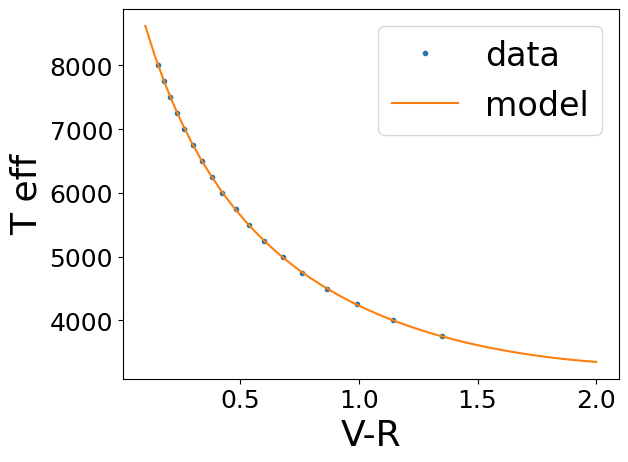

In [82]:
# test fitting

V_R_test = np.linspace(0.1, 2)

Teff_VR_test = VR_to_Teff(V_R_test)

plt.plot(V_Rs, t_effs, '.', label='data')
plt.plot(V_R_test, Teff_VR_test, label='model')
plt.legend()
plt.xlabel('V-R')
plt.ylabel('T eff')



#### R-I to Teff

In [97]:
t_effs = np.array([3750,  4000,  4250,  4500,  4750,  5000,  5250, 5500,  5750,  6000, 6250, 6500, 6750, 7000,  7250, 7500, 7750, 8000])

R_Is = np.array([1.005, 0.815, 0.690, 0.595, 0.520, 0.460, 0.405,0.360, 0.320, 0.285,0.255,0.225,0.2, 0.175, 0.155, 0.135, 0.120, 0.100])

Theta = 5040 / t_effs


In [98]:
np.polyfit(R_Is, np.log10(t_effs), deg=2)

array([ 0.36852784, -0.75623926,  3.96836573])

In [99]:
np.polyfit(R_Is, Theta, deg=3)

array([-0.00372186, -0.48393689,  1.32916366,  0.50060817])

In [100]:
def RI_to_Teff(RI, model='poly'):
    """
    """
    RI = np.asarray(RI)

    # value from np.polyfit
    if model=='poly':
        # only works for RI<1
        a3, a2, a1, a0 = -0.00372186, -0.48393689,  1.32916366,  0.50060817
    
        Theta = a0 + a1 * RI + a2 * RI ** 2 + a3 * RI ** 3

        return 5040 / Theta
    
    if model=='exp':
        a3, a2, a1, a0 = -0.2610645,  0.78625533, -0.93975579,  3.98867204
        #a3, a2, a1, a0 = 0, 0.36852784, -0.75623926,  3.96836573
        logTeff = a0 + a1 * RI + a2 * RI ** 2 + a3 * RI ** 3
    
        return 10 ** logTeff


Text(0, 0.5, 'T eff')

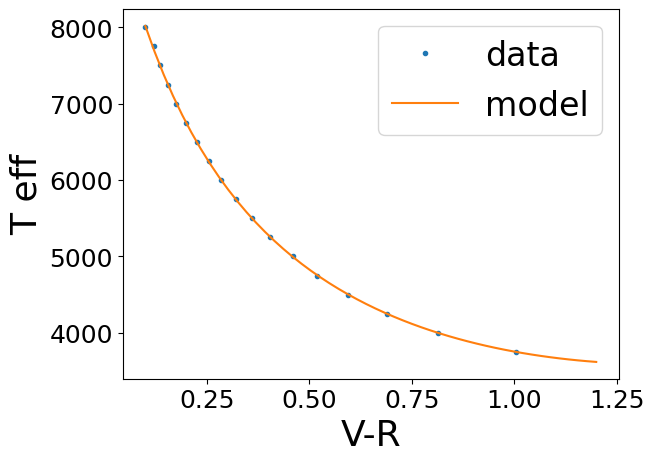

In [105]:
# test fitting

R_I_test = np.linspace(0.1, 1.2)

Teff_RI_test = RI_to_Teff(R_I_test, model='poly')

plt.plot(R_Is, t_effs, '.', label='data')
plt.plot(R_I_test, Teff_RI_test, label='model')
plt.legend()
plt.xlabel('V-R')
plt.ylabel('T eff')


Text(0, 0.5, 'T eff')

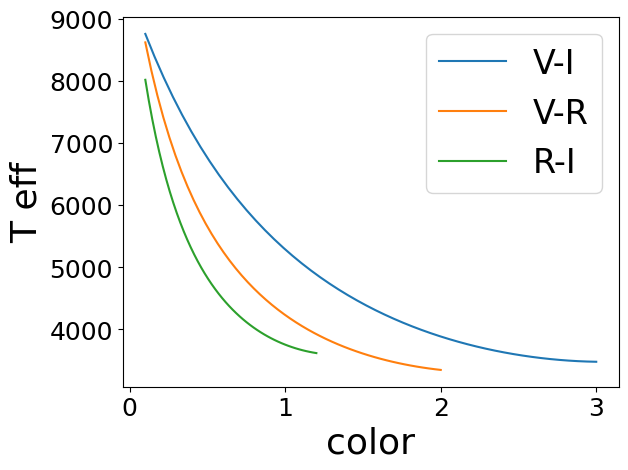

In [106]:
# test fitting
plt.plot(V_I_test, Teff_VI_test, label='V-I')

plt.plot(V_R_test, Teff_VR_test, label='V-R')

plt.plot(R_I_test, Teff_RI_test, label='R-I')

plt.legend()
plt.xlabel('color')
plt.ylabel('T eff')



### griz to VRI

https://www.sdss3.org/dr8/algorithms/sdssUBVRITransform.php#Jordi2006

Jordi et al. (2005)


In [66]:
def gi_to_VI(gi):
    """
    Convert g-i to V-I, from
    https://www.sdss3.org/dr8/algorithms/sdssUBVRITransform.php#Jordi2006
    """
    VI = (0.675)*(gi)  + (0.364)
    return VI

def gr_to_VR(gr):
    """
    Convert g-r to V-R, from
    https://www.sdss3.org/dr8/algorithms/sdssUBVRITransform.php#Jordi2006
    """
    VR = 1/1.646 * gr + 0.139 / 1.646
    return VR

def ri_to_RI(ri):
    """
    Convert ri to R-I, from
    https://www.sdss3.org/dr8/algorithms/sdssUBVRITransform.php#Jordi2006
    """
    RI = (0.930)*ri + (0.259)
    
    return RI

def rz_to_RI(rz):
    RI = rz/1.584 + 0.386/1.584

    return RI

def iz_to_RI(iz):
    # convert iz to RI
    #iz = rz - ri
    RI = 1 / (1.584 - 1/0.930) * iz + (0.386 - 0.259/0.930) / (1.584 - 1/0.930)
    return RI


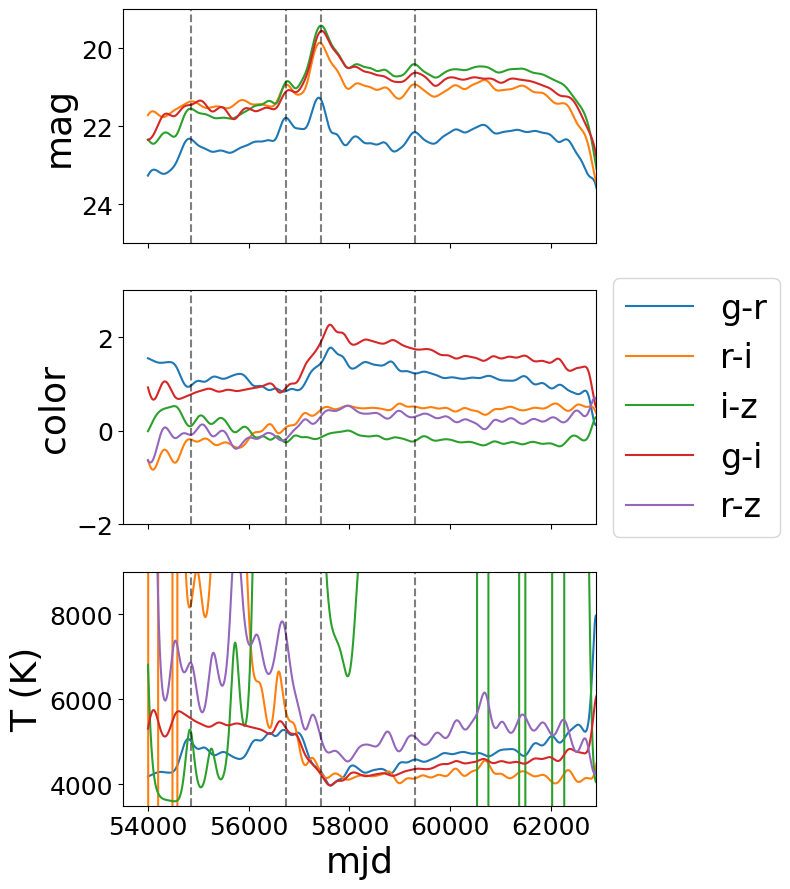

In [124]:
fig, axs = plt.subplots(3, 1, sharex=True, figsize=(8, 9))

ax = axs[0]

ax.plot(t_ran, g_new)
ax.plot(t_ran, r_new)
ax.plot(t_ran, i_new)
ax.plot(t_ran, z_new)

ax.invert_yaxis()
ax.set_ylabel('mag')
ax.set_ylim([25, 19])

ax = axs[1]

color_gr = g_new - r_new
color_ri = r_new - i_new
color_iz = i_new - z_new
color_gi = g_new - i_new
color_rz = r_new - z_new

ax.plot(t_ran, color_gr, label='g-r')
ax.plot(t_ran, color_ri, label='r-i')
ax.plot(t_ran, color_iz, label='i-z')
ax.plot(t_ran, color_gi, label='g-i')
ax.plot(t_ran, color_rz, label='r-z')

ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.set_ylabel('color')

ax.set_ylim([-2, 3])

ax = axs[2]
T_gr = VR_to_Teff( gr_to_VR(color_gr) )
T_ri = RI_to_Teff( ri_to_RI(color_ri) )
T_iz = RI_to_Teff( iz_to_RI(color_iz) )

T_gi = VI_to_Teff( gi_to_VI(color_gi) )
T_rz = RI_to_Teff( rz_to_RI(color_rz) )

ax.plot(t_ran, T_gr, label='g-r')
ax.plot(t_ran, T_ri, label='r-i')
ax.plot(t_ran, T_iz, label='i-z')
ax.plot(t_ran, T_gi, label='g-i')
ax.plot(t_ran, T_rz, label='r-z')

ax.set_ylim([3500, 9000])
ax.set_xlabel('mjd')
ax.set_ylabel('T (K)')

for ax in axs:
    ax.axvline( 54850, color='k', ls='--', alpha=0.5)
    ax.axvline( 56740, color='k', ls='--', alpha=0.5)
    ax.axvline( 57430, color='k', ls='--', alpha=0.5)
    ax.axvline( 59300, color='k', ls='--', alpha=0.5)
    ax.set_xlim([53500, 57430 + 15*365])

fig.tight_layout()


### estimate from blackbody spectra

In [125]:
import numpy as np
from scipy.optimize import fsolve

# Constants
h = 6.626e-27       # erg*s
c = 2.998e18        # Å/s
k = 1.381e-16       # erg/K

# SDSS effective wavelengths in Angstrom
lambda_g = 4770
lambda_r = 6370
lambda_i = 7785
lambda_z = 9155

# observed color
g_i_obs = 1.0  # example

def color_eq(T, g_i_obs, lambda_1, lambda_2):
    # estimate temperature from lambda_1 - lambda_2
    # 
    
    B_ratio = (lambda_2**5 / lambda_1**5) * (
        (np.exp(h*c/(lambda_2*k*T)) - 1) / (np.exp(h*c/(lambda_1*k*T)) - 1)
    )
    return -2.5 * np.log10(B_ratio) - g_i_obs

T_eff = fsolve(color_eq, 6000, (g_i_obs, lambda_g, lambda_i))[0]
print("Effective temperature:", T_eff)



Effective temperature: 3470.079443689998


In [126]:
import numpy as np

# --- Physical constants in convenient units ---
h  = 6.62607015e-27       # erg·s
c  = 2.99792458e18        # Å/s
k  = 1.380649e-16         # erg/K

# --- SDSS effective wavelengths in Å ---
lambda_g = 4770.0
lambda_i = 7785

def B_lambda_angstrom(lam, T):
    """
    Planck function B_lambda in cgs with λ in Å.
    Returns arbitrary units (ratio is what matters).
    """
    x = h*c/(lam*k*T)
    return (2*h*c**2) / (lam**5 * (np.exp(x) - 1))

def gi_from_T(T):
    """Return g-i color for blackbody of temperature T (K)."""
    Bg = B_lambda_angstrom(lambda_g, T)
    Bi = B_lambda_angstrom(lambda_i, T)
    return -2.5 * np.log10(Bg / Bi)


/var/folders/yb/hm0wbr8128v_fbvy474l5s6m0000gn/T/ipykernel_180/2422759602.py:23: RuntimeWarning: overflow encountered in exp
  (np.exp(h*c/(lambda_2*k*T)) - 1) / (np.exp(h*c/(lambda_1*k*T)) - 1)
/var/folders/yb/hm0wbr8128v_fbvy474l5s6m0000gn/T/ipykernel_180/2422759602.py:23: RuntimeWarning: invalid value encountered in divide
  (np.exp(h*c/(lambda_2*k*T)) - 1) / (np.exp(h*c/(lambda_1*k*T)) - 1)
/var/folders/yb/hm0wbr8128v_fbvy474l5s6m0000gn/T/ipykernel_180/3070331111.py:5: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  T_eff = fsolve(color_eq, 4000, (i, lambda_g, lambda_r))[0]
/var/folders/yb/hm0wbr8128v_fbvy474l5s6m0000gn/T/ipykernel_180/3070331111.py:15: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  T_eff = fsolve(color_eq, 4000, (i, lambda_r, lambda_i))[0]
/var/folders/yb/hm0wbr8128v_fbvy474l5s6m0000gn/T/ipykernel_180/3070331111.p

Text(0, 0.5, 'T(K)')

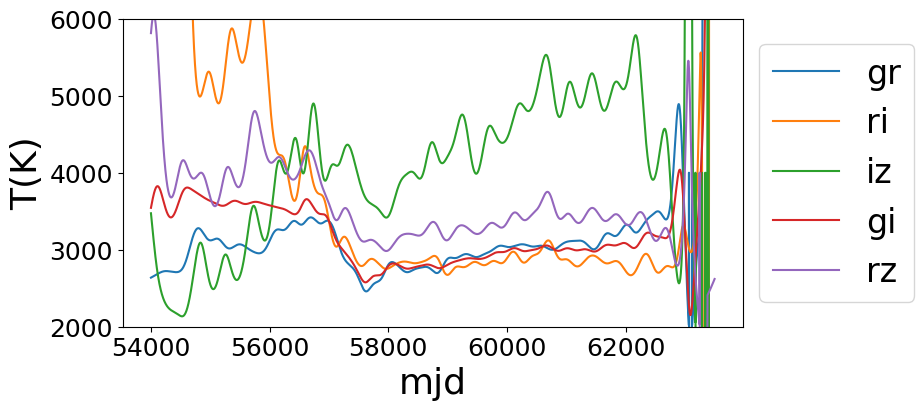

In [128]:

plt.figure(figsize=(8, 4))

teff = []
for i in color_gr:
    T_eff = fsolve(color_eq, 4000, (i, lambda_g, lambda_r))[0]
    teff.append(T_eff)

plt.plot(t_ran, teff, label='gr')

plt.ylim([2000, 6000])
#--------------

teff = []
for i in color_ri:
    T_eff = fsolve(color_eq, 4000, (i, lambda_r, lambda_i))[0]
    teff.append(T_eff)

plt.plot(t_ran, teff, label='ri')

plt.ylim([2000, 6000])


#----------------
teff = []
for i in color_iz:
    T_eff = fsolve(color_eq, 4000, (i, lambda_i, lambda_z))[0]
    teff.append(T_eff)

plt.plot(t_ran, teff, label='iz')

plt.ylim([2000, 6000])

#-----------------

teff = []
for i in color_gi:
    T_eff = fsolve(color_eq, 4000, (i, lambda_g, lambda_i))[0]
    teff.append(T_eff)

plt.plot(t_ran, teff, label='gi')


# -----------------------------
teff = []
for i in color_rz:
    T_eff = fsolve(color_eq, 4000, (i, lambda_r, lambda_z))[0]
    teff.append(T_eff)

plt.plot(t_ran, teff, label='rz')


# ---------------------

plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.xlabel('mjd')

plt.ylabel('T(K)')

